In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd())) #Add project dir to path
from utils.syncUtilities import plotFramesShiftToSyncrhonizeAllSubjectsOneActivity,getMainJointFromMotAndMainBonesFromCSV, getSamplesToSynchronize, SynchronizeAndCutSignals

## Computes ideal synchronization of IMU and video data records by estimating the RMSE of shifted signals (_.mot_ and _.csv_), and writes this info into `infoToSync.csv`.

In [2]:
import utils.fileProcessing as fileutil 
import utils.plotUtilities as plotutil
import utils.signalProcessing as signalutil

Set dataset root path

In [3]:
fulldatasetpath = '/mnt/b/VIDIMU'

In [4]:
inpath = os.path.join(fulldatasetpath,'extra', 'dataset','videoandimus')
outpath = os.path.join(fulldatasetpath,'extra', 'analysis','videoandimusync')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### 1. Synchronization in loop for a list of subjects and activities

In [5]:
lower_activities = ["A01"]
dataset_activities = lower_activities
activities_legend = ["walk_forward"]

In [6]:
subjects = ["S40","S41"]

In [7]:
RMSE_SAMPLES = 180
FINAL_LENGTH= 180 
MAX_SYNC_OVERLAP = 15

Activity: A01
Not found
Not found


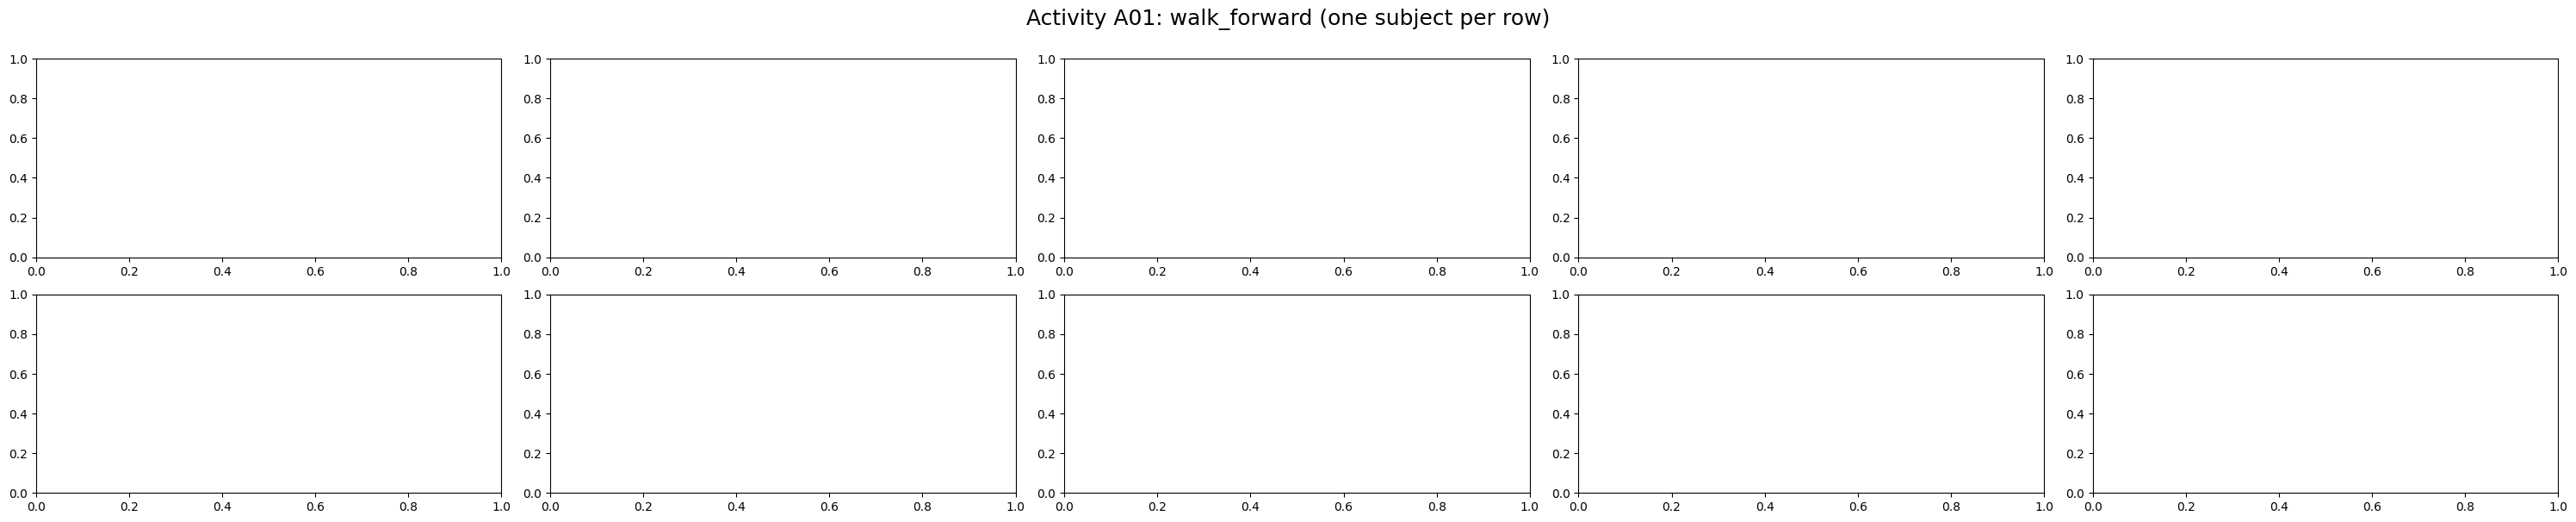

In [8]:
rmse_lists = []
index_activity = 0

csvlog='infoToSync.csv'
csvlogfile = os.path.join(outpath,csvlog)
if os.path.exists(csvlogfile):
    os.remove(csvlogfile)
for activity,legend in zip(dataset_activities,activities_legend):
    print("Activity: "+activity)
    rmse_list = plotFramesShiftToSyncrhonizeAllSubjectsOneActivity(csvlog,inpath,outpath,subjects,activity,legend,activity+"_("+legend+")_synchronize",RMSE_SAMPLES=RMSE_SAMPLES,MAX_SYNC_OVERLAP=MAX_SYNC_OVERLAP,FINAL_LENGTH=FINAL_LENGTH)